In [1]:
import pandas as pd
import numpy as np

# Load Jambeck dataset (192 countries)
df = pd.read_csv('Plastic Waste - Jambeck et al. (2015).csv')
print(" NEW Dataset shape:", df.shape)
print("\n Key columns:")
print(df.columns.tolist())
df.head()


 NEW Dataset shape: (187, 14)

 Key columns:
['Entity', 'Year', 'Coastal population', 'Per capita waste generation rate', 'Share of plastics in waste stream', 'Share of plastic inadequately managed', 'Municipal waste generated', 'Plastic waste generated', 'Inadequately managed plastic waste', 'Plastic waste littered', 'Per capita mismanaged plastic waste', 'Total mismanaged plastic waste in 2010', 'Total mismanaged plastic waste in 2025', 'Per capita plastic waste (kg/person/day)']


,Entity,Year,Coastal population,Per capita waste generation rate,Share of plastics in waste stream,Share of plastic inadequately managed,Municipal waste generated,Plastic waste generated,Inadequately managed plastic waste,Plastic waste littered,Per capita mismanaged plastic waste,Total mismanaged plastic waste in 2010,Total mismanaged plastic waste in 2025,Per capita plastic waste (kg/person/day)
0,Albania,2010,2530533.0,0.77,9.0,45.0,1948510.0,174392.0,77897.0,3488.0,0.032,29705,63051,0.069
1,Algeria,2010,16556580.0,1.20,12.0,58.0,19867896.0,2374214.0,1378693.0,47484.0,0.086,520555,1017444,0.144
2,Angola,2010,3790041.0,0.48,13.0,71.0,1819220.0,235589.0,166597.0,4712.0,0.045,62528,136770,0.062
3,Anguilla,2010,14561.0,2.10,12.0,2.0,30578.0,3654.0,68.0,73.0,0.010,52,73,0.252
4,Antigua and Barbuda,2010,66843.0,5.50,12.0,6.0,367637.0,43933.0,2555.0,879.0,0.051,1253,1385,0.660


In [ ]:
# Calculate YOUR required features
df['Coastal_Density'] = df['Coastal population'] / 1000000  # people/km² proxy (per million)
df['MWI'] = df['Share of plastic inadequately managed'] / 100  # % → 0-1 scale
df['Target_Ocean_MT'] = pd.to_numeric(df['Plastic waste littered'], errors='coerce')  # metric tons

# Clean data
df_clean = df[['Coastal_Density', 'MWI', 'Target_Ocean_MT']].dropna()
print(f" Training data: {len(df_clean)} rows")
print("\n Feature stats:")
print(df_clean.describe())


✅ Training data: 186 rows

📊 Feature stats:
       Coastal_Density         MWI  Target_Ocean_MT
count       186.000000  186.000000       186.000000
mean         10.869870    0.346344     29303.989247
std          31.126835    0.341310     84042.661479
min           0.000596    0.000000         3.000000
25%           0.233337    0.000000       797.250000
50%           1.794752    0.240000      3099.000000
75%           7.442666    0.737500     21462.000000
max         262.892387    0.880000    754588.000000


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Split data
X = df_clean[['Coastal_Density', 'MWI']]
y = df_clean['Target_Ocean_MT']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# NEW MODEL - 200 trees for 192 countries
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# Results
y_pred = model.predict(X_test)
print(f" Test R²: {r2_score(y_test, y_pred):.3f}")
print(f" MAE: {mean_absolute_error(y_test, y_pred):,.0f} tons")
print(f" Coastal Density importance: {model.feature_importances_[0]:.1%}")
print(f" MWI importance: {model.feature_importances_[1]:.1%}")


🎯 Test R²: 0.686
📏 MAE: 3,227 tons
🌟 Coastal Density importance: 86.6%
🌟 MWI importance: 13.4%


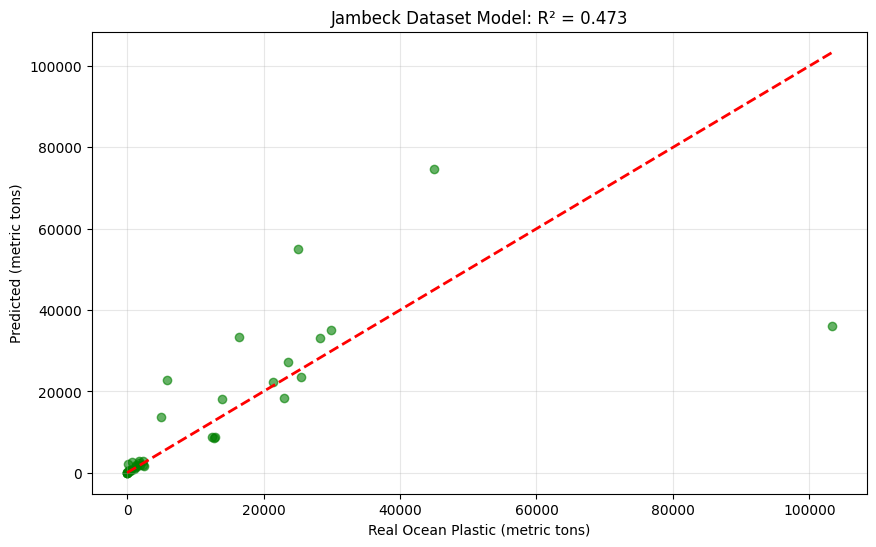


🔮 Predictions:
Test 1: 27,663 metric tons
Test 2: 107,236 metric tons
Test 3: 2,946 metric tons


c:\Users\Dhanyashree\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\Dhanyashree\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\Dhanyashree\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [ ]:
import matplotlib.pyplot as plt

# Plot results
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Real Ocean Plastic (metric tons)')
plt.ylabel('Predicted (metric tons)')
plt.title(f'Jambeck Dataset Model: R² = {r2_score(y_test, y_pred):.3f}')
plt.grid(True, alpha=0.3)
plt.show()

# Real-world predictions
print("\n Predictions:")
tests = [[10, 0.3], [50, 0.8], [1, 0.1]]  # density, MWI
for i, test in enumerate(tests,1):
    pred = model.predict([test])[0]
    print(f"Test {i}: {pred:,.0f} metric tons")
